In [1]:
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms.functional import resize, to_pil_image
from PIL import Image

In [2]:
import json
import os

def get_coco_captions(image_file_name, coco_file_path='./asset/captions_val2017.json'):
    """
    根据 COCO caption 标注文件，返回指定图像文件名对应的所有描述语句（captions）。
    
    Args:
        image_file_name (str): 图像文件名，例如 '000000039769.jpg'
        coco_file_path (str): captions json 文件路径（默认 './asset/captions_val2017.json'）
    
    Returns:
        captions (list[str]): 该图像对应的所有文字描述
    """
    if not os.path.exists(coco_file_path):
        raise FileNotFoundError(f"COCO captions file not found: {coco_file_path}")

    # 读取 json 文件
    with open(coco_file_path, 'r') as f:
        coco_data = json.load(f)

    # 建立 image_id -> file_name 映射
    image_id_map = {img['id']: img['file_name'] for img in coco_data['images']}

    # 找到与输入文件名对应的 image_id
    target_id = None
    for img_id, fname in image_id_map.items():
        if fname == image_file_name:
            target_id = img_id
            break
    if target_id is None:
        raise ValueError(f"Image file name '{image_file_name}' not found in {coco_file_path}")

    # 收集所有与该 image_id 对应的 caption
    captions = [ann['caption'] for ann in coco_data['annotations'] if ann['image_id'] == target_id]

    return captions

In [30]:
get_coco_captions('000000047571.jpg')

['Some people sit in a carriage pulled by a horse. ',
 'A group of people that are on a horse.',
 'A horse pulls a small carriage in which two people are riding.',
 'A pair of people ride a small, horse drawn buggy near a large puddle of water.',
 'A horse drawn carriage being pulled through the mud']

In [4]:
@torch.no_grad()
def compute_patch_change_map(model, pixel_values, input_ids, attention_mask):
    """
    返回：
      delta_map: [H_p, W_p] 的 numpy，H_p=W_p=24（对于 336/14 的 CLIP）
      per_scale_maps: List[np.ndarray]，每个 scale 的 24x24 差分（在频域融合前、上采样回原patch尺度后的贡献）
    """
    model.eval()
    device = next(model.parameters()).device

    # 1) 取原始倒数第二层视觉特征（包含 CLS + 576 patch）
    vision_outputs = model.vision_model(
        pixel_values=pixel_values.to(device),
        output_hidden_states=True,
        return_dict=True,
    )
    V_pre = vision_outputs['hidden_states'][-2]            # [B, 577, D_v]
    B, S, Dv = V_pre.shape
    assert S == 1 + (model.image_size // model.patch_size) ** 2  # 1+576

    # 2) 文本池化特征（与你forward一致的做法）
    text_outputs = model.text_model(
        input_ids=input_ids.to(device),
        attention_mask=attention_mask.to(device),
        output_hidden_states=True,
        return_dict=True,
    )
    T_last2 = text_outputs['hidden_states'][-2]            # [B, T, Dt]
    T_mask = attention_mask.to(device).unsqueeze(-1)       # [B,T,1]
    T_pooled = (T_last2 * T_mask).sum(dim=1) / (T_mask.sum(dim=1) + 1e-6)  # [B,Dt]

    # 3) 通过 freq_adapter + 视觉最后一层（和你forward一致）
    V_adapted_input = model.freq_adapter(V_pre, T_pooled)  # [B,577,Dv] (已把 patch 区域替换)
    last_layer_out = model.vision_model.encoder.layers[-1](V_adapted_input, None, None, output_attentions=False)[0]
    V_post = model.vision_model.post_layernorm(last_layer_out)  # [B,577,Dv]

    # 4) 计算 patch 级差分（不包含 CLS）
    pre_patch = V_pre[:, 1:, :]     # [B,576,Dv]
    post_patch = V_post[:, 1:, :]   # [B,576,Dv]
    delta = torch.norm(post_patch - pre_patch, p=2, dim=-1)   # [B,576]

    # 5) reshape 成 24x24
    H_p = W_p = int((S - 1) ** 0.5)
    delta_map = delta.view(B, H_p, W_p)  # [B,24,24]

    # 6) 取 per-scale（来自前面在 forward 里缓存的 _last_per_scale_ups）
    per_scale_maps = []
    if hasattr(model.freq_adapter, "_last_per_scale_ups"):
        per_scales = model.freq_adapter._last_per_scale_ups  # List[ [B,576,Dv], ... ]
        print(len(per_scales))
        for X in per_scales:
            print(X.shape)
            # 以“该scale贡献带来的改变量量级”来衡量：取其 L2 范数（空域上的 per-patch 通道范数）
            m = torch.norm(X, p=2, dim=-1).view(B, H_p, W_p)  # [B,24,24]
            per_scale_maps.append(m)

    return delta_map[0].cpu().numpy(), [m[0].cpu().numpy() for m in per_scale_maps]

In [5]:
def show_image(img: Image.Image):
    # heatmap resize 到图像大小
    h, w = img.size[1], img.size[0]  # PIL: width,height np.ptp(arr, ...)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [22]:
def overlay_heatmap_on_image(img: Image.Image, heatmap_2d: np.ndarray, alpha=0.5):
    # heatmap resize 到图像大小
    h, w = img.size[1], img.size[0]  # PIL: width,height np.ptp(arr, ...)
    hm = Image.fromarray((255 * (heatmap_2d - heatmap_2d.min()) / (np.ptp(heatmap_2d) + 1e-6)).astype(np.uint8))
    hm = hm.resize((img.size[0], img.size[1]), Image.NEAREST)
    hm = np.array(hm)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(hm, alpha=alpha)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


2025-10-06 18:54:41.839 | INFO     | frequency_adapter.models.FreqAdapterModel:set_adapter:294 - Set freq adapter: use_mcfa: True, use_mgfa: True, use_freq_adapter: True, share: False


use freq adapter
3
torch.Size([1, 576, 1024])
torch.Size([1, 576, 1024])
torch.Size([1, 576, 1024])


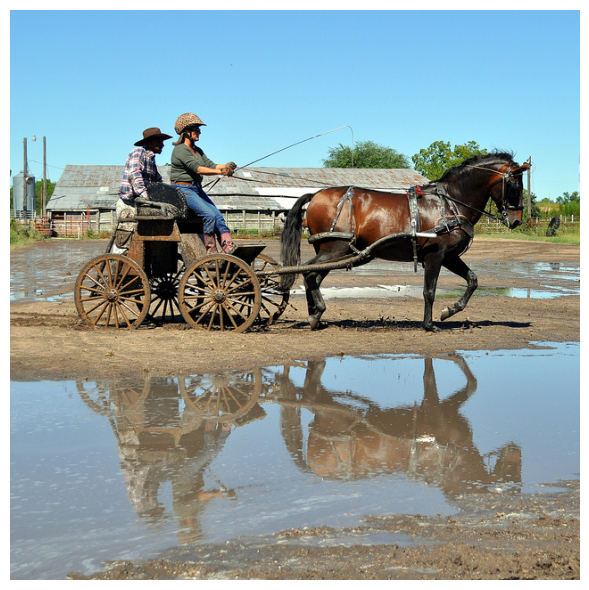

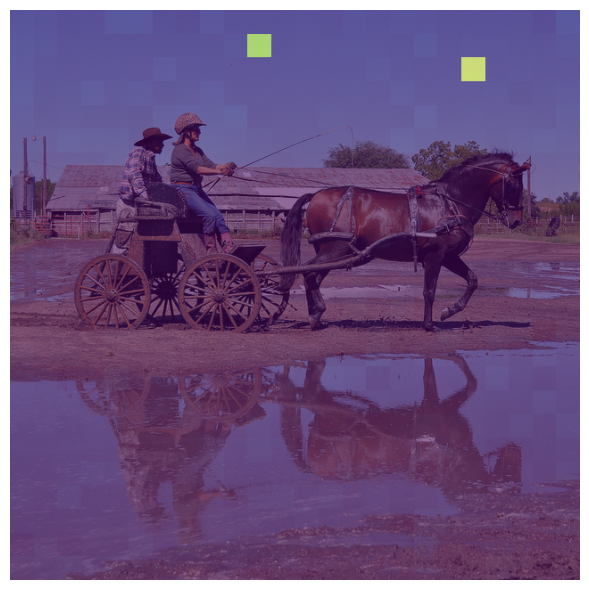

Scale 0 contribution map


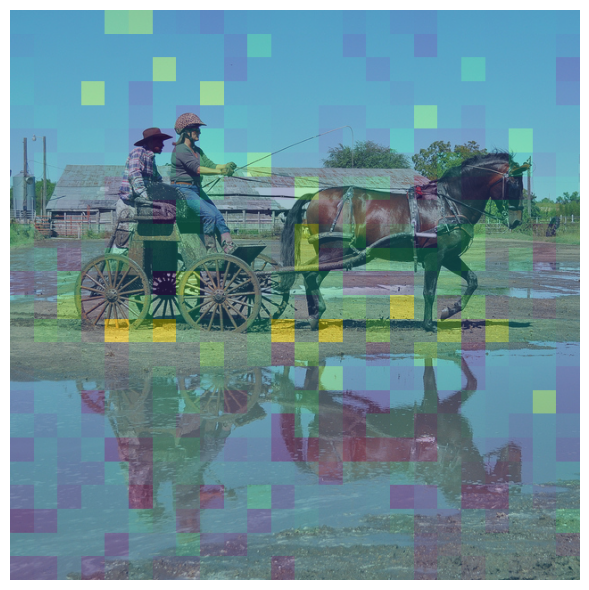

Scale 1 contribution map


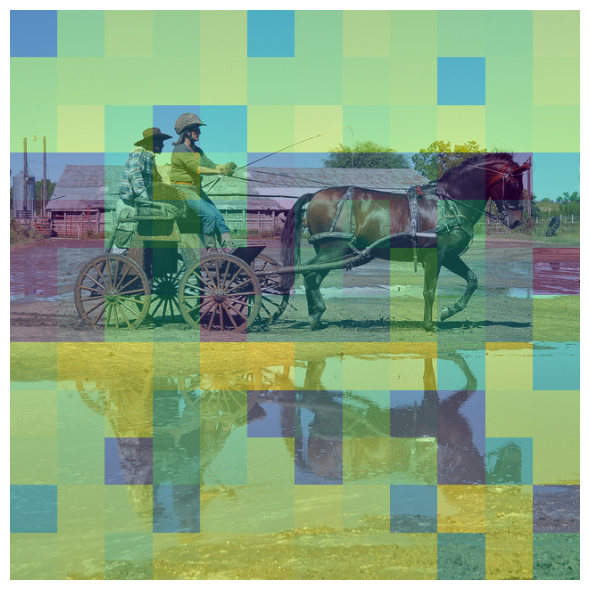

Scale 2 contribution map


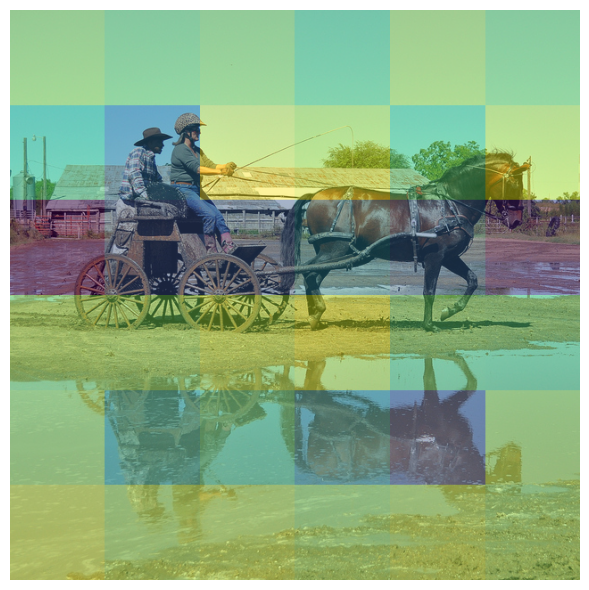

In [ ]:

from transformers import CLIPModel, CLIPProcessor
from frequency_adapter.models import FreqApdapterModel
model_name_or_path = '/home/workspace/freq_adapter/CKPT/freq_adapter_0_2025-10-06_02-38-00'
model = FreqApdapterModel.from_pretrained(model_name_or_path, torch_dtype=torch.float16)
model.set_adapter(enable_mcfa=True, enable_mgfa=True, use_freq_adapter=True)
model.eval()
model = model.cuda()

# 你可以用自己的图片和文本
your_pil_image = Image.open("/home/workspace/freq_adapter/asset/000000031118.jpg").convert("RGB")  # 替换成你的图片路径
your_texts = ["Series of light decorations at a city center with a tree and a clock tower. "]  # 替换成你的文本列表


processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14-336")
batch = processor(text=your_texts, images=your_pil_image, return_tensors="pt", padding=True)

delta_map, per_scale_maps = compute_patch_change_map(
    model, batch["pixel_values"], batch["input_ids"], batch["attention_mask"]
)
show_image(your_pil_image)
# 叠加显示
overlay_heatmap_on_image(your_pil_image, delta_map, alpha=0.45)

# 分别看每个 scale 的贡献热力图
for i, m in enumerate(per_scale_maps):
    print(f"Scale {i} contribution map")
    overlay_heatmap_on_image(your_pil_image, m, alpha=0.45)